# 02 — Preprocessing
**Traffic Sign Recognition · GTSRB Dataset**

Goals:
- Crop images to their ROI bounding box (removes background clutter)
- Apply CLAHE contrast enhancement (fixes dark / washed-out images)
- Resize to 64×64 with Lanczos interpolation (sharp result)
- Normalise pixel values to [0, 1]
- Save `X.npy` and `y.npy` so later notebooks can load instantly

> **Bugs fixed vs original notebook**
> - `roi['y2']` → `roi_coords['y2']` (KeyError otherwise)
> - `IMG_SIZE` raised from 32 → **64** for noticeably sharper images
> - Added CLAHE contrast enhancement for better image quality

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from src.config import DATA_DIR, IMG_SIZE
from src.data_loader import load_csv
from src.preprocessing import preprocess_image, load_dataset

print(f"Target image size : {IMG_SIZE}×{IMG_SIZE}")
print(f"Data directory    : {DATA_DIR}")

2026-02-28 00:51:41.545395: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-28 00:51:41.579318: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 00:51:42.139563: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 00:51:54.025225: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Target image size : 64×64
Data directory    : /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/data


## 1. Visualise Preprocessing Steps on a Single Image

Train CSV  :  39209 rows  |  columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Meta  CSV  :     43 rows  |  columns: ['Path', 'ClassId', 'ShapeId', 'ColorId', 'SignId']


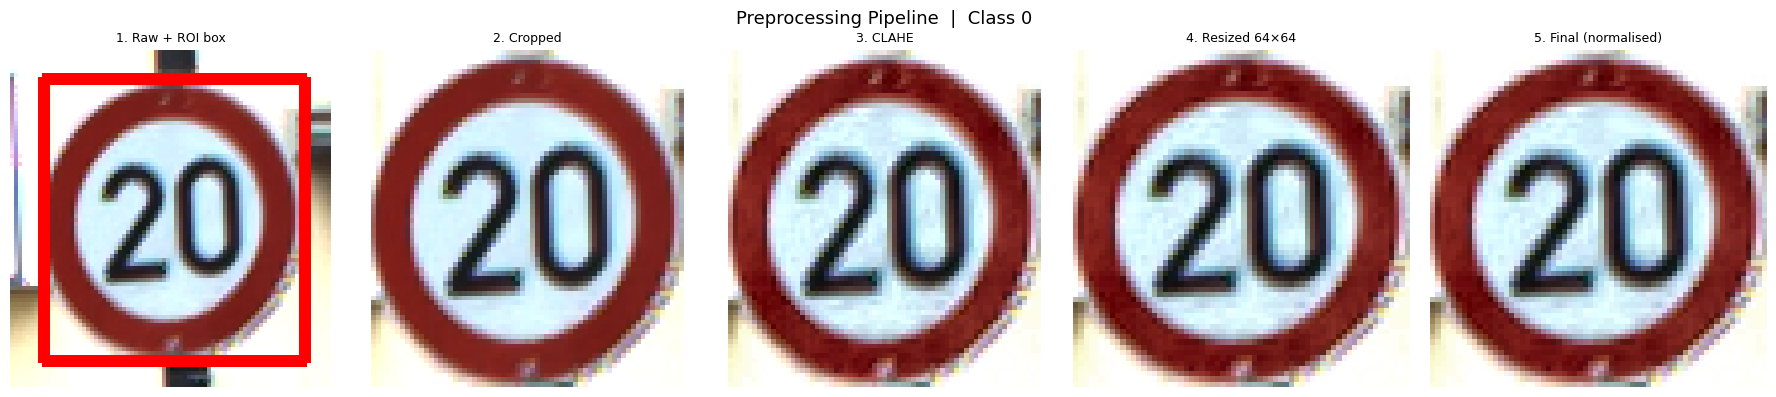

Raw shape      : (84, 80, 3)
Cropped shape  : (70, 65, 3)
Final shape    : (64, 64, 3)
Pixel range    : [0.000, 1.000]


In [2]:
train_df, _ = load_csv(DATA_DIR)

sample_idx = 500
row = train_df.iloc[sample_idx]
full_path = os.path.join(DATA_DIR, row['Path'])

# ── Load raw ────────────────────────────────────────────────────────────────
raw = cv2.imread(full_path)
raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)

roi = {'x1': row['Roi.X1'], 'y1': row['Roi.Y1'],
       'x2': row['Roi.X2'], 'y2': row['Roi.Y2']}

# ── Step-by-step ────────────────────────────────────────────────────────────
# Step 1: draw ROI box
raw_roi = raw.copy()
cv2.rectangle(raw_roi,
              (int(roi['x1']), int(roi['y1'])),
              (int(roi['x2']), int(roi['y2'])),
              (255, 0, 0), 2)

# Step 2: crop
cropped = raw[int(roi['y1']):int(roi['y2']), int(roi['x1']):int(roi['x2'])]

# Step 3: CLAHE
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
lab = cv2.cvtColor(cropped, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)
l_eq = _clahe.apply(l)
clahe_img = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2RGB)

# Step 4: resize
resized = cv2.resize(clahe_img, (IMG_SIZE, IMG_SIZE),
                     interpolation=cv2.INTER_LANCZOS4)

# Step 5: full pipeline (normalised)
final = preprocess_image(full_path, roi, use_clahe=True, target_size=IMG_SIZE)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
titles = ['1. Raw + ROI box', '2. Cropped', '3. CLAHE', f'4. Resized {IMG_SIZE}×{IMG_SIZE}', '5. Final (normalised)']
images = [raw_roi, cropped, clahe_img, resized, final]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle(f'Preprocessing Pipeline  |  Class {row["ClassId"]}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Raw shape      : {raw.shape}")
print(f"Cropped shape  : {cropped.shape}")
print(f"Final shape    : {final.shape}")
print(f"Pixel range    : [{final.min():.3f}, {final.max():.3f}]")

## 2. Compare: with vs without CLAHE

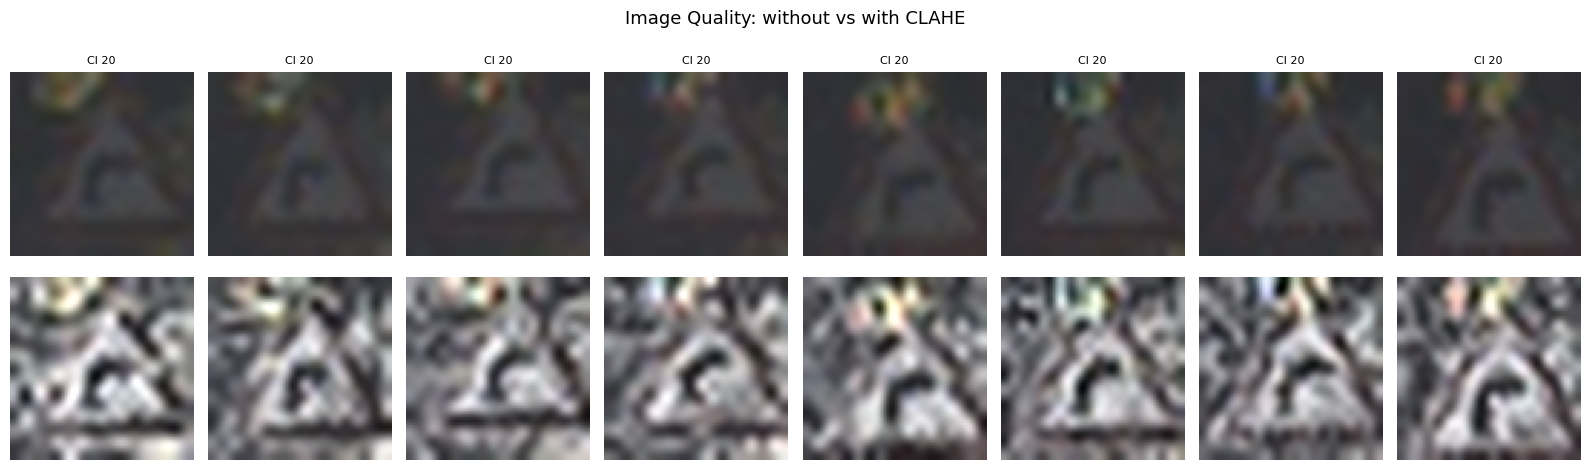

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

indices = list(range(0, 8))   # first 8 samples
for col, idx in enumerate(indices):
    r = train_df.iloc[idx]
    p = os.path.join(DATA_DIR, r['Path'])
    roi_c = {'x1': r['Roi.X1'], 'y1': r['Roi.Y1'],
             'x2': r['Roi.X2'], 'y2': r['Roi.Y2']}

    without = preprocess_image(p, roi_c, use_clahe=False)
    with_cl = preprocess_image(p, roi_c, use_clahe=True)

    axes[0, col].imshow(without)
    axes[0, col].set_title(f'Cl {r["ClassId"]}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(with_cl)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('No CLAHE', fontsize=10)
axes[1, 0].set_ylabel('With CLAHE', fontsize=10)
plt.suptitle('Image Quality: without vs with CLAHE', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Load Entire Dataset

This cell may take **5–15 minutes** depending on your hardware.  
The arrays are saved to disk so you only need to run this once.

In [4]:
CACHE_X = os.path.join(DATA_DIR, "X.npy")
CACHE_Y = os.path.join(DATA_DIR, "y.npy")

if os.path.exists(CACHE_X) and os.path.exists(CACHE_Y):
    print("Loading cached arrays …")
    X = np.load(CACHE_X)
    y = np.load(CACHE_Y)
else:
    print("Processing images (this takes a few minutes) …")
    X, y = load_dataset(train_df, DATA_DIR, use_roi=True, use_clahe=True)
    np.save(CACHE_X, X)
    np.save(CACHE_Y, y)
    print("Arrays saved to data/X.npy and data/y.npy")

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {len(np.unique(y))}")

Processing images (this takes a few minutes) …
  [    0/39209] processed …
  [ 1000/39209] processed …
  [ 2000/39209] processed …
  [ 3000/39209] processed …
  [ 4000/39209] processed …
  [ 5000/39209] processed …
  [ 6000/39209] processed …
  [ 7000/39209] processed …
  [ 8000/39209] processed …
  [ 9000/39209] processed …
  [10000/39209] processed …
  [11000/39209] processed …
  [12000/39209] processed …
  [13000/39209] processed …
  [14000/39209] processed …
  [15000/39209] processed …
  [16000/39209] processed …
  [17000/39209] processed …
  [18000/39209] processed …
  [19000/39209] processed …
  [20000/39209] processed …
  [21000/39209] processed …
  [22000/39209] processed …
  [23000/39209] processed …
  [24000/39209] processed …
  [25000/39209] processed …
  [26000/39209] processed …
  [27000/39209] processed …
  [28000/39209] processed …
  [29000/39209] processed …
  [30000/39209] processed …
  [31000/39209] processed …
  [32000/39209] processed …
  [33000/39209] processed …
 

## 4. Grid of Preprocessed Samples

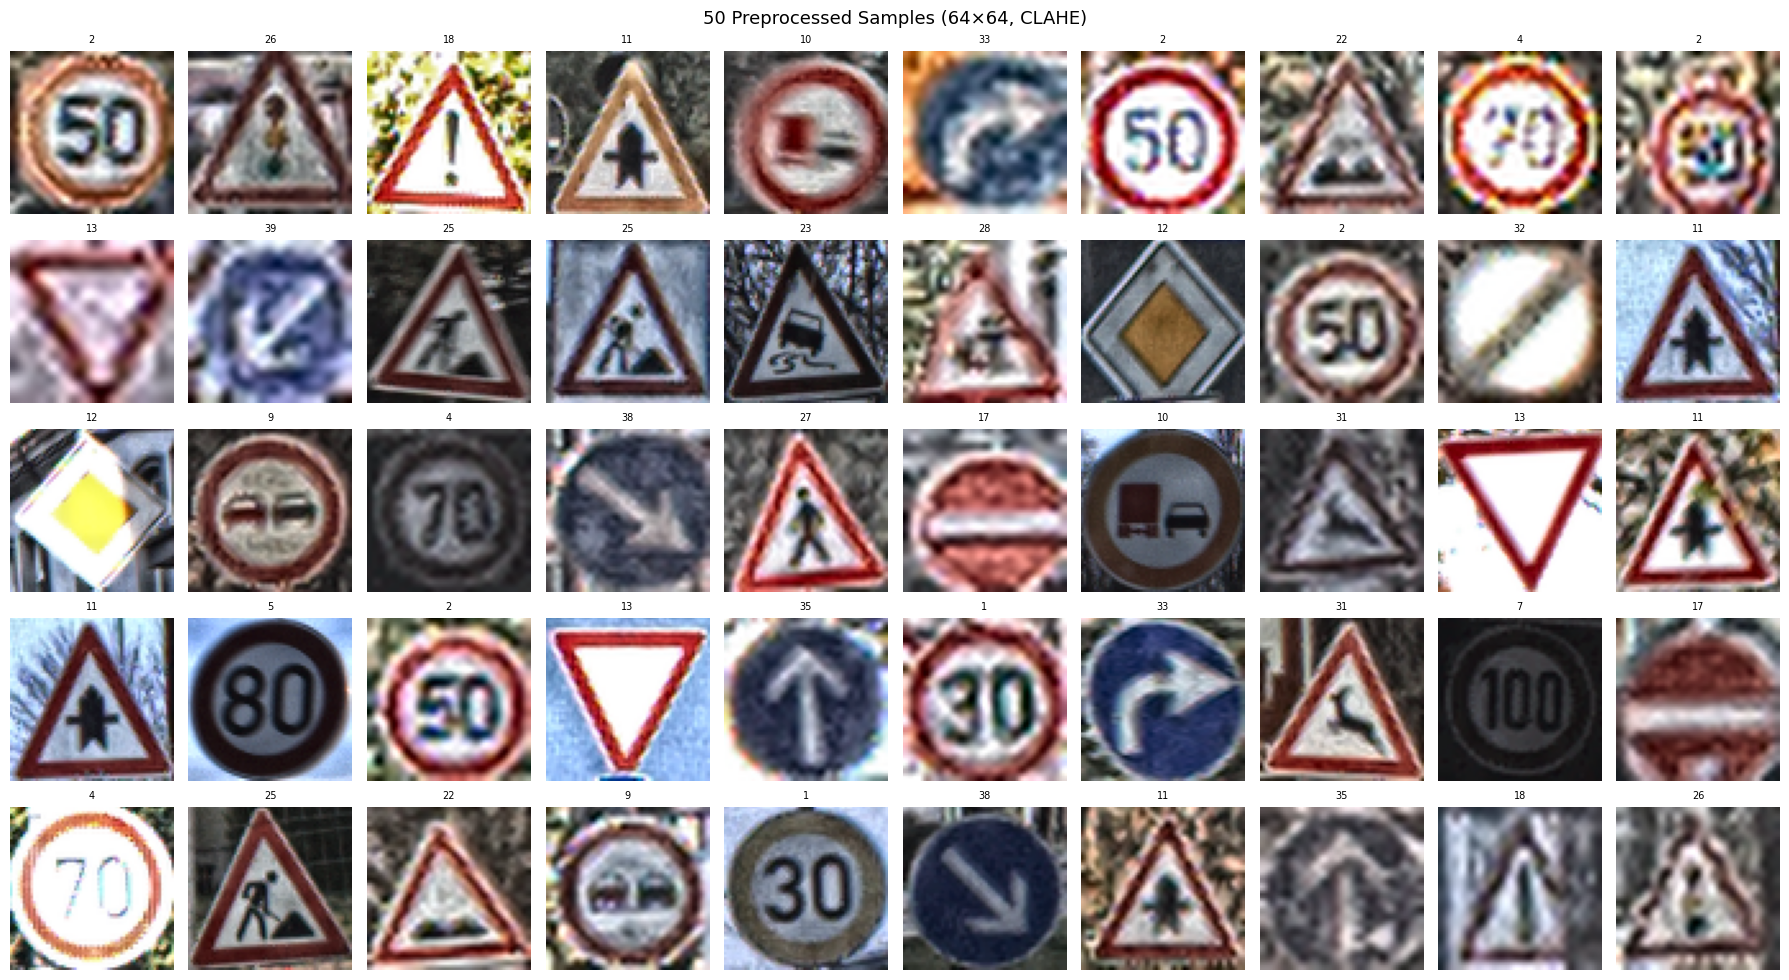

In [5]:
fig, axes = plt.subplots(5, 10, figsize=(18, 10))
axes = axes.ravel()
rng = np.random.default_rng(42)
indices = rng.integers(0, len(X), size=50)

for i, idx in enumerate(indices):
    axes[i].imshow(X[idx])
    axes[i].set_title(f'{y[idx]}', fontsize=7)
    axes[i].axis('off')

plt.suptitle(f'50 Preprocessed Samples ({IMG_SIZE}×{IMG_SIZE}, CLAHE)',
             fontsize=13)
plt.tight_layout()
plt.show()